In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize

from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser, getionimage

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from skimage import transform, filters
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
    print("WARNING: SimpleITK not installed. B-spline registration unavailable.")
    print("Install with: pip install SimpleITK")
from pyimzml.ImzMLParser import ImzMLParser
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
FULL_HE_PATH = '/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif'
IMZML_PATH = '/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML'
MALDI_IMG = '/home/kia/MALDI_Metabolomics/metabol_data/maldi_moving_img.png'

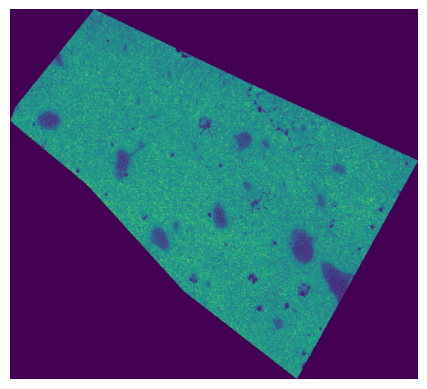

In [3]:
imzml_path = Path(IMZML_PATH)
maldi_parser = ImzMLParser(imzml_path)
ion_mat = getionimage(maldi_parser, 78.958, tol=.0042)

# plot the image w/o borders
def plot_fake_img(img, pic_name, cmap='viridis'):
    plt.figure(frameon=False)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()
plot_fake_img(ion_mat, 'maldi_moving_img')

save the image in the exact dimensions given 

In [ ]:
import cv2
cv2.imwrite(MALDI_IMG, (ion_mat / ion_mat.max() * 255).astype(np.uint8))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pick_landmarks_matplotlib(he_image, maldi_image, n_points):
    print(f"\n{'='*60}\nLANDMARK SELECTION -- click {n_points} vessel pairs\n{'='*60}")
    
    if type(he_image) == sitk.Image:
        print('SimpleITK image format...changing to numpy array')
        he_image = sitk.GetArrayFromImage(he_image)
        maldi_image = sitk.GetArrayFromImage(maldi_image) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    ax1.imshow(he_image);    ax1.set_title("H&E -- FIRST",   fontweight="bold"); ax1.axis("off")
    ax2.imshow(maldi_image); ax2.set_title("MALDI -- SECOND", fontweight="bold"); ax2.axis("off")

    he_pts, maldi_pts, current = [], [], ["he"]

    def onclick(event):
        if event.inaxes is None:
            return
        x, y = event.xdata, event.ydata

        if event.inaxes == ax1 and current[0] == "he":
            if len(he_pts) < n_points:
                he_pts.append([x, y])
                i = len(he_pts)
                ax1.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax1.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"H&E landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(he_pts) == n_points:
                current[0] = "maldi"
                ax2.set_title("MALDI -- CLICK NOW", fontweight="bold", color="red")
                fig.canvas.draw_idle()

        elif event.inaxes == ax2 and current[0] == "maldi":
            if len(maldi_pts) < n_points:
                maldi_pts.append([x, y])
                i = len(maldi_pts)
                ax2.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax2.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"MALDI landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(maldi_pts) == n_points:
                ax2.set_title("MALDI -- COMPLETE! Close window.", fontweight="bold", color="green")
                fig.canvas.mpl_disconnect(cid)
                fig.canvas.draw()
                plt.close(fig)  # unblocks plt.show(block=True)
                return

        fig.canvas.draw_idle()

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show(block=True)  # blocks here until all landmarks are picked

    print("Landmark selection complete.")
    return np.array(he_pts, dtype=float), np.array(maldi_pts, dtype=float)

In [ ]:
def down_sample_sitk(img: sitk, factor: int): 
    # Original size and spacing
    original_size = img.GetSize()
    original_spacing = img.GetSpacing()

    # New size should be as close as possible to the downsample factor
    new_size = [max(1, int(round(s / factor))) for s in original_size]

    # Adjust spacing so physical dimensions stay the same
    new_spacing = [sp * (original_size[i] / new_size[i])
                   for i, sp in enumerate(original_spacing)]

    # Resample
    downsampled = sitk.Resample(
        img,
        new_size,
        sitk.Transform(),
        sitk.sitkLinear,  # use sitkNearestNeighbor for label masks
        img.GetOrigin(),
        new_spacing,
        img.GetDirection(),
        0,
        img.GetPixelID()
)
    return downsampled

In [ ]:
# load the images and preprocesses them.

""" SimpleITK landmark registration """
%matplotlib tk
import SimpleITK as sitk

# Build sitk images directly from the arrays — no PNG round-trip
fixed_img = sitk.ReadImage(FULL_HE_PATH, sitk.sitkFloat32)
fixed_img.SetSpacing([1.0, 1.0])
fixed_img.SetOrigin([0.0, 0.0])

moving_image = sitk.ReadImage(MALDI_IMG, sitk.sitkFloat32)
moving_image.SetSpacing([1.0, 1.0])
moving_image.SetOrigin([0.0, 0.0])

# Downsample only the H&E for landmark picking, keep MALDI at native size.
df_factor = 4
fixed_ds = down_sample_sitk(fixed_img, df_factor)

# Picker shows the downsampled H&E and native MALDI image.
fixed_landmarks, moving_landmarks = pick_landmarks_matplotlib(fixed_ds, moving_image, n_points=4)

# Convert picked points into physical coordinates for both images.
fixed_landmarks_phys = np.array([fixed_ds.TransformContinuousIndexToPhysicalPoint(pt)
                                 for pt in fixed_landmarks], dtype=float)
moving_landmarks_phys = np.array([moving_image.TransformContinuousIndexToPhysicalPoint(pt)
                                  for pt in moving_landmarks], dtype=float)

# Fit only rotation + translation — scale is already resolved
landmark_initializer = sitk.LandmarkBasedTransformInitializerFilter()
landmark_initializer.SetFixedLandmarks(fixed_landmarks_phys.flatten().tolist())
landmark_initializer.SetMovingLandmarks(moving_landmarks_phys.flatten().tolist())

#transform = sitk.AffineTransform(2) # Affine shearing is too intense for global registration
transform = sitk.AffineTransform(2)

# use only 3 landmark pairs minimum to fit rotation + translation
output_transform = landmark_initializer.Execute(transform)
print(output_transform)

# Resample moving onto fixed original image space
output_image = sitk.Resample(
    moving_image,
    fixed_img,
    output_transform,
    sitk.sitkLinear,
    0
)

checking to see if the initial alignment gives us a reasonable coordinate structure 

# Fine Scale Alignment

In [ ]:
# Build a ones-image with the same geometry as the MALDI
ones_arr = np.ones(sitk.GetArrayFromImage(moving_image).shape[:2], dtype=np.float32)
maldi_ones = sitk.GetImageFromArray(ones_arr)
maldi_ones.CopyInformation(moving_image)

# Warp it: 1 where MALDI exists, exactly 0 elsewhere
coverage = sitk.Resample(maldi_ones, fixed_img, output_transform,
                         sitk.sitkNearestNeighbor, 0.0)
mask = sitk.GetArrayFromImage(coverage) > 0.5

ys, xs = np.where(mask)
y_min, y_max = int(ys.min()), int(ys.max()) + 1
x_min, x_max = int(xs.min()), int(xs.max()) + 1

he_img = skio.imread(FULL_HE_PATH)
cropped_img = he_img[y_min:y_max, x_min:x_max]
# save the cropped image 
skio.imsave(fname='/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif', arr=cropped_img)
#plt.imshow(cropped_img)

getting the cropped image into the original coordinates

In [ ]:
he_img = skio.imread(FULL_HE_PATH)
cropped_img = skio.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif')

# blank canvas matching the full H&E
reconstructed = np.zeros_like(he_img)

# place the crop back at its original position
reconstructed[y_min:y_max, x_min:x_max] = cropped_img

In [ ]:
plt.imshow(he_img)
plt.imshow(reconstructed, alpha=0.5)

Got the initial transform done with the correct cropped region 

### Sinusoid Mask

In [ ]:
from pathlib import Path
# grey scale normalization
IMAGE_PATH = Path('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif') 
bgr  = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

In [4]:

def dbscan_1d_ish(imzml_path: str, mz_tol: float, min_intensity: float, min_count: int) -> pd.DataFrame:
    """
    Perform DBSCAN-like clustering on the m/z values in the dataframe. Clusters for now
    will be defined as contiguous regions where the difference between adjacent m/z values is less than mz_tol.
    Clusters with fewer than min_count points will be flagged as "noise".

    :param mz_tol: the tolerance for the m/z values
    :param min_intensity: the minimum intensity for a m/z to be considered
    :param min_count: the minimum number of points to form a cluster

    :return: a DataFrame with additional columns for delta_mz, in_dense_region, and cluster_labels
    :rtype: pandas.DataFrame
    """
    parser = ImzMLParser(imzml_path)
    df =pd.DataFrame(
                (   # neat trick to unpack the mzs and intensities directly into the row
                    # * is a unpacking operator called splat and it unpacks the tuple of mzs and intensities
                    # from getspectrum into individual elements in the new tuple
                    (*parser.getspectrum(idx), (x,y)) for idx, (x,y,_) in enumerate(parser.coordinates)
                ),
                    columns=["mzs", "intensities", "coordinates"]
        )
    # pull raw arrays out of the dataframe — no copies yet
    mzs_arr    = df['mzs'].to_numpy()
    intens_arr = df['intensities'].to_numpy()
    coords_arr = df['coordinates'].to_numpy()

    # single-pass concatenation — much faster than explode
    all_mzs    = np.concatenate(mzs_arr).astype(np.float32)
    all_intens = np.concatenate(intens_arr).astype(np.float32)
    lengths    = np.fromiter((len(a) for a in mzs_arr), dtype=np.int32, count=len(mzs_arr))
    all_coords = np.repeat(coords_arr, lengths)

    # filter BEFORE building the dataframe — avoids allocating rows you'll discard
    mask       = all_intens > min_intensity
    all_mzs    = all_mzs[mask]
    all_intens = all_intens[mask]
    all_coords = all_coords[mask]

    # sort on numpy arrays — faster than df.sort_values + reset_index
    print(f"Sorting m/z values...{mask.sum()} values")
    order      = np.argsort(all_mzs, kind='stable')

    print(f"building long_df")
    long_df = pd.DataFrame({
        'mzs':         all_mzs[order],
        'intensities': all_intens[order],
        'coordinates': all_coords[order],
    })

    
    print(f'\nlong_df columns: {long_df.columns}\n')  # print the columns of long_df.columns)
    
    # check if long
    # find the deltas between adjacent m/z values
    print("calculating deltas")
    delta_values = -1 * long_df['mzs'].values[0:(len(long_df) - min_count)] + long_df['mzs'].values[min_count:(len(long_df) + min_count)]
    
    # 0 padding missing values to match the length of the dataframe
    long_df['delta_mz'] = np.concatenate([delta_values, [0] * min_count])
    del delta_values

    # creating a boolean mask for regions where delta_mz < mz_tol
    long_df['in_dense_region'] = (long_df['delta_mz'] < mz_tol).astype(int)

    # Calculating difference of boolean flags
    # Calculate diff without fillna to get proper length n-1
    difference = np.diff(long_df['in_dense_region'].values)
    difference_plus = np.maximum(difference, 0)
    running_clusternr = np.cumsum(difference_plus)
    del difference
    del difference_plus

    # intermediate vector of of boolean flags
    delta = long_df['in_dense_region'].values

    # Now both have compatible shapes: delta[:-1] and running_clusternr are both length n-1
    clusternr = delta[:-1] * running_clusternr
    del running_clusternr

    # 0 padding missing values to match the length of the dataframe
    long_df['cluster_labels'] = np.concatenate([[delta[0]], clusternr])
    del clusternr
    del delta

    # Remove noise clusters
    # going to prune the data
    long_df = long_df[long_df["cluster_labels"] != 0]

    # Remove clusters with fewer than N mz values
    long_df = long_df[long_df.groupby('cluster_labels') ['mzs'].transform('size') >= min_count]

    import scipy.sparse as sp

    # grouping mzs based on the median of the cluster labels, and summing the intensities for each coordinate and mz_label pair
    print("Grouping m/z values and summing intensities...")
    grouped = (
        long_df
        .assign(mz_label=long_df.groupby('cluster_labels')['mzs'].transform('median'))
        .groupby(['coordinates', 'mz_label'])['intensities']
        .sum()
    )

    # Build integer codes for rows (coordinates) and cols (mz_label)
    print("Getting the coordinate and mz labels")
    coord_idx, coord_labels = pd.factorize(grouped.index.get_level_values('coordinates'))
    mz_idx,    mz_labels    = pd.factorize(grouped.index.get_level_values('mz_label'))
    
    # making it sparse to save memory
    print("Generating spot x feature matrix (sparse)...")
    spot_feature_matrix = sp.csr_matrix(
        (grouped.values, (coord_idx, mz_idx)),
        shape=(len(coord_labels), len(mz_labels))
    )


    return spot_feature_matrix, coord_labels, mz_labels


In [5]:
imzml_path = "/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML"

In [6]:
spot_feature_matrix, coord_labels, mz_labels = dbscan_1d_ish(imzml_path, mz_tol=0.0042, min_intensity=5, min_count=25)

Sorting m/z values...39694844 values
building long_df

long_df columns: Index(['mzs', 'intensities', 'coordinates'], dtype='object')

calculating deltas
Grouping m/z values and summing intensities...
Getting the coordinate and mz labels
Generating spot x feature matrix (sparse)...


In [ ]:
from skimage import color, morphology
from skimage.segmentation import clear_border

def compute_sinusoid_mask_from_he(he_img,
                                  max_size=10000,
                                  min_size=100,
                                  otsu_bias=1.0):
    # grayscale brightness
    gray = color.rgb2gray(he_img)               # (H, W), range [0, 1]

    # min(R,G,B) — high only when all channels are high (truly white)
    rgb_min = he_img.min(axis=-1)               # (H, W), range [0, 1]

    # combine: a pixel must be bright in both — filters pink (bright gray, low blue)
    white_signal = np.minimum(gray, rgb_min)    # (H, W)

    thr = threshold_otsu(white_signal) * otsu_bias
    interior = clear_border(white_signal > thr)

    large_enough = morphology.remove_small_objects(interior, max_size=min_size - 1)
    too_large    = morphology.remove_small_objects(interior, max_size=max_size - 1)
    return (large_enough ^ too_large).astype(np.float32)



In [ ]:
# getting the map from MALDI to H&E coordinates using the inverse of the output_transform
inv_transform = output_transform.GetInverse()

# getting the coordinates of the MALDI pixels in the H&E space using the inverse transform
parser = ImzMLParser(imzml_path)
maldi_coords = [[x, y] for x, y, _ in parser.coordinates]

# apply to all MALDI coordinates at once
T0_maldi_coords = np.array([inv_transform.TransformPoint((float(x), float(y)))
                       for x, y in maldi_coords])
T0_maldi_coords

In [ ]:
import matplotlib.image as mpimg

ion_mat = getionimage(parser, 78.958, tol=0.0042)
png_img = mpimg.imread(MALDI_IMG)

print("Raw MALDI grid shape:", ion_mat.shape)   # (Hm, Wm) — actual grid
print("PNG shape used in reg:", png_img.shape)   # (H, W) — what transform knows about


In [7]:
import skimage

# then we get our sinusoid mask from the H&E image called S_HE in the manuscript
cropped_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif')
he_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif')

In [8]:
maldi_coord_map = pd.read_csv('/home/kia/MALDI_Metabolomics/metabol_data/space_ranger_segmented_outputs/cell_segmentations_out3_pixel_warp_affine_vs_tps.csv')

# Align by native MSI pixel identity (msi_x, msi_y) rather than assuming the
# CSV's row order matches spot_feature_matrix's row order. pandas.groupby
# (used to build coord_labels in dbscan_1d_ish) sorts its keys by default,
# so coord_labels is NOT in the CSV's original row order — using positional
# alignment here would silently pair every MSI feature row with the wrong
# H&E-space coordinate.
msi_to_he = dict(zip(
    zip(maldi_coord_map['msi_x'].astype(float), maldi_coord_map['msi_y'].astype(float)),
    zip(maldi_coord_map['he_x_tps'], maldi_coord_map['he_y_tps'])
))
T0_maldi_coords = np.array([msi_to_he[(float(x), float(y))] for x, y in coord_labels])

xs = T0_maldi_coords[:, 0]
ys = T0_maldi_coords[:, 1]

x_min, x_max = int(xs.min()), int(xs.max()) + 1
y_min, y_max = int(ys.min()), int(ys.max()) + 1

In [ ]:
# correct — Otsu sees only real tissue pixels
S_HE = compute_sinusoid_mask_from_he(cropped_img)

# if you need it back in full H&E coordinates afterward:
S_HE_full = np.zeros(he_img.shape[:2], dtype=np.float32)
S_HE_full[y_min:y_max, x_min:x_max] = S_HE

plt.imshow(S_HE_full)
plt.title("Sinusoid mask from H&E")
plt.show()

In [10]:
cleaned_sinusoid_mask = skimage.io.imread('/home/kia/MALDI_Metabolomics/sinusoid_mask.tif')
#plt.imshow(cleaned_sinusoid_mask)

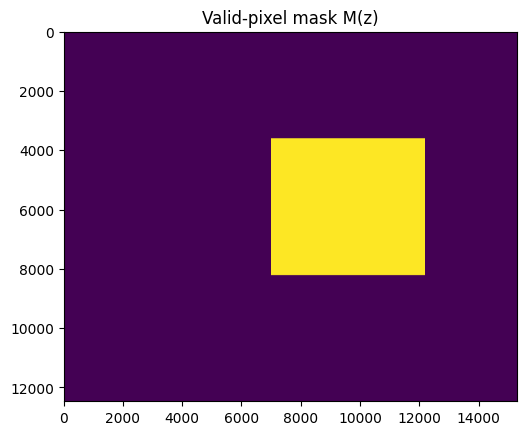

In [11]:
def build_valid_pixel_mask(full_shape, y_min, y_max, x_min, x_max):
    """
    Valid-pixel mask M(z) for the H&E image (paper Sec. 2.1).

    S_HE_full is zero everywhere outside the cropped tissue bounding box
    [y_min:y_max, x_min:x_max] — that's padding, not "no sinusoid here".
    M marks the region where S_HE_full actually carries information, so the
    Wendland convolution can be locally re-normalized instead of treating
    the padded border as real background.
    """
    M = np.zeros(full_shape[:2], dtype=np.float32)
    M[y_min:y_max, x_min:x_max] = 1.0
    return M

M = build_valid_pixel_mask(he_img.shape, y_min, y_max, x_min, x_max)

plt.imshow(M)
plt.title("Valid-pixel mask M(z)")
plt.show()

In [12]:
import numpy as np
from scipy.signal import convolve2d


def _create_wendland_kernel(h):
    """
    Create normalized Wendland C2 kernel.

    h = kernel support parameter
    """

    radius = int(np.ceil(np.sqrt(h)))

    x = np.arange(-radius, radius+1) # x length of kernel (2*radius+1)
    y = np.arange(-radius, radius+1) # y length (same as x)

    X, Y = np.meshgrid(x, y) # building the kernel grid 

    r2 = X**2 + Y**2 # radial area of influence

    kernel = np.zeros_like(r2, dtype=float) # making the kernel with the same shape as r2 but filled with zeros

    inside = r2 < h # boolean mask for the points that are within the cutoff radius h

    kernel[inside] = (
        (1 - r2[inside]/h)**4 *
        (4*r2[inside]/h + 1)
    ) # function for Wendland C2 kernel (determines influence of each pixel based on distance from center)

    # normalize C_h
    kernel /= kernel.sum()

    return kernel



def smooth_HE_mask(S_HE, h):
    """
    Wendland smoothing of binary H&E mask.

    S_HE:
        binary numpy array

    h:
        kernel support parameter
    """

    K_h = _create_wendland_kernel(h)

    S_HE_tilde = convolve2d(
        S_HE,
        K_h,
        mode="same",
        boundary="symm"
    )

    return S_HE_tilde

#S_HE_tilde = smooth_HE_mask(S_HE_full, h)
#plt.imshow(S_HE_tilde)
#plt.title("Smoothed sinusoid mask from H&E")
#plt.show()

In [13]:
from sklearn.neighbors import NearestNeighbors

# get the nearest neighbors of the T0_maldi_coords and the distance between these points 
neigh = NearestNeighbors(n_neighbors=2)
neigh.fit(T0_maldi_coords)
distances, _ = neigh.kneighbors(T0_maldi_coords)
r = np.median(distances[:, 1])
h = 1.5*r

In [14]:
def smooth_mask_normalized(S_HE, M, h):
    """
    Locally-normalized Wendland smoothing (paper Sec. 2.1, eq. for f(z)).

    Plain convolution of S_HE alone treats padding outside the valid H&E
    domain as real "no sinusoid" background, dimming values near the crop
    edge. Instead we also convolve the valid-pixel mask M and divide it
    out, so each output pixel is renormalized by how much *valid* support
    the kernel actually had at that location.
    """
    K_h = _create_wendland_kernel(h)

    # numerator: raw smoothed sinusoid signal
    N = convolve2d(S_HE, K_h, mode="same", boundary="fill", fillvalue=0)

    # denominator: how much of the kernel's support fell inside valid H&E data
    D = convolve2d(M, K_h, mode="same", boundary="fill", fillvalue=0)

    # only defined where the kernel had at least some valid support
    f = np.zeros_like(N, dtype=np.float32)
    valid = D > 0
    f[valid] = N[valid] / D[valid]
    return f

S_smooth = smooth_mask_normalized(cleaned_sinusoid_mask, M, h)

#plt.imshow(S_smooth)
#plt.title("Boundary-corrected smoothed sinusoid mask f(z)")
#plt.show()

In [15]:
from scipy.ndimage import map_coordinates
def project_to_msi(S_smooth, T_U):
    """
    S_smooth: smoothed H&E image
    T_U: (N,2) transformed MSI coordinates in H&E space
    """

    # scipy uses (row, col) = (y, x)
    coords = np.vstack([T_U[:,1], T_U[:,0]])

    values = map_coordinates(
        S_smooth,
        coords,
        order=1,      # bilinear interpolation
        mode='nearest'
    )

    return values


s_T0 shape: (269511,)
s_T0 range: 0.0 to 1.0


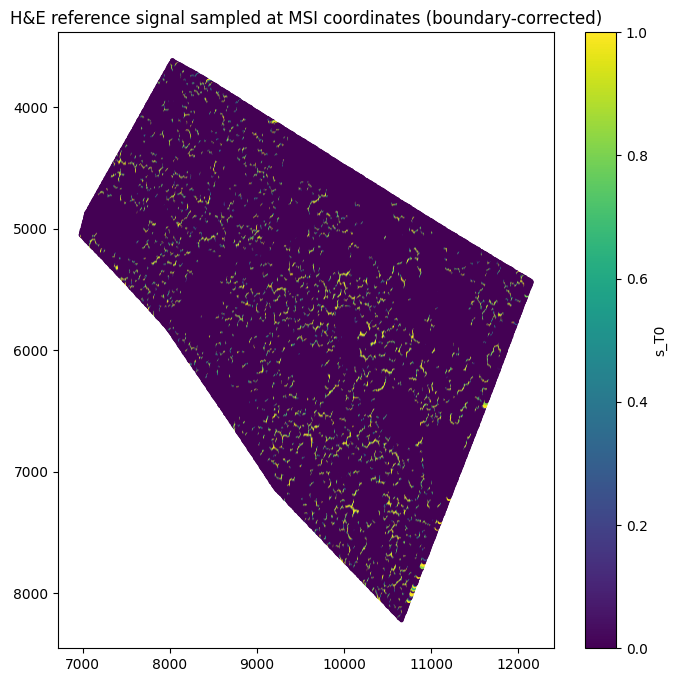

In [16]:
# s_T0(i) = f(T0(u_i)) — sample the boundary-corrected smooth field at each
# MSI pixel's H&E-space coordinate (paper Sec. 1, s_T definition). One row
# per MALDI spot, same order as spot_feature_matrix.
s_T0 = project_to_msi(S_smooth, T0_maldi_coords)

print("s_T0 shape:", s_T0.shape)
print("s_T0 range:", s_T0.min(), "to", s_T0.max())

plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=s_T0, s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title("H&E reference signal sampled at MSI coordinates (boundary-corrected)")
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

def preprocess_features(spot_feature_matrix, low_pct=1, high_pct=99):
    """
    MSI feature preprocessing before ridge fitting (paper Sec. 2.2 requires
    centered/unit-variance features; TIC normalization and outlier clipping
    are standard MSI preprocessing added on top of that).
    """
    X = spot_feature_matrix.toarray().astype(np.float32)

    # TIC (total ion current) normalization: divide each spot's intensities
    # by their sum, correcting for per-spot differences in overall
    # ionization efficiency before comparing intensities across spots.
    #tic = X.sum(axis=1, keepdims=True)
    #tic[tic == 0] = 1.0  # guard against empty spots
    #X = X / tic

    # clip each feature at its 1st/99th percentile so a handful of extreme
    # spots don't dominate the per-column mean/std computed next.
    lo = np.percentile(X, low_pct, axis=0)
    hi = np.percentile(X, high_pct, axis=0)
    X = np.clip(X, lo, hi)

    # center and scale each feature to unit variance
    X_scaled = StandardScaler().fit_transform(X)
    return X_scaled

X_scaled = preprocess_features(spot_feature_matrix)

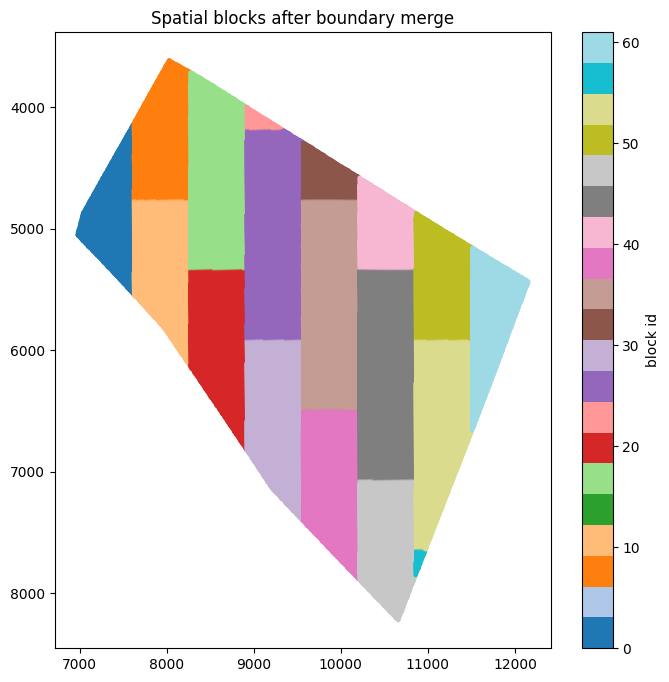

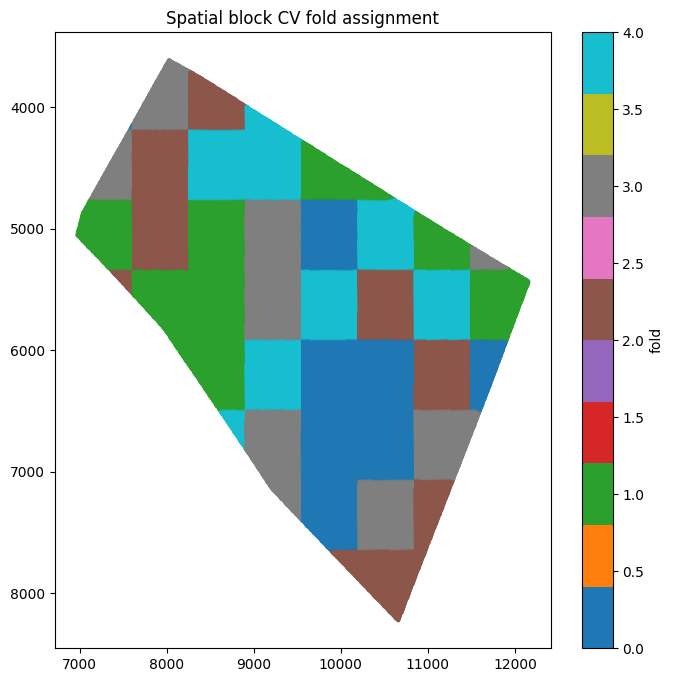

In [18]:
def spatial_block_cv(coords, n_blocks_per_axis=8, n_folds=5, min_block_size=20, random_state=0):
    """
    Spatial block CV fold assignment (paper Sec. 2.2). Random per-pixel folds
    would leak spatial autocorrelation between train/val; blocking on
    contiguous regions of the tissue avoids that.
    """
    x, y = coords[:, 0], coords[:, 1]
    x_edges = np.linspace(x.min(), x.max() + 1e-6, n_blocks_per_axis + 1)
    y_edges = np.linspace(y.min(), y.max() + 1e-6, n_blocks_per_axis + 1)
    bx = np.digitize(x, x_edges[1:-1])
    by = np.digitize(y, y_edges[1:-1])
    block_id = bx * n_blocks_per_axis + by

    # merge undersized boundary blocks into a grid-adjacent block that
    # already has enough points (paper Sec. 2.2: "merged with neighbouring blocks").
    unique_blocks, counts = np.unique(block_id, return_counts=True)
    for small_id in unique_blocks[counts < min_block_size]:
        bxi, byi = divmod(small_id, n_blocks_per_axis)
        neighbors = [(bxi + dx, byi + dy) for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]
                     if 0 <= bxi + dx < n_blocks_per_axis and 0 <= byi + dy < n_blocks_per_axis]
        for nbx, nby in neighbors:
            nb_id = nbx * n_blocks_per_axis + nby
            if nb_id != small_id and (block_id == nb_id).sum() >= min_block_size:
                block_id[block_id == small_id] = nb_id
                break

    # greedily assign blocks (in random order) to whichever fold currently has fewest pixels
    unique_blocks, counts = np.unique(block_id, return_counts=True)
    order = np.random.RandomState(random_state).permutation(len(unique_blocks))
    fold_loads = np.zeros(n_folds)
    block_to_fold = {}
    for idx in order:
        f = np.argmin(fold_loads)
        block_to_fold[unique_blocks[idx]] = f
        fold_loads[f] += counts[idx]

    fold_assignment = np.array([block_to_fold[b] for b in block_id])
    return block_id, fold_assignment

block_id, fold_assignment = spatial_block_cv(T0_maldi_coords)

# blocks after boundary merge — grid-adjacency version should keep straight,
# axis-aligned block edges everywhere, including at the tissue boundary
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=block_id, s=4, cmap="tab20")
plt.gca().invert_yaxis()
plt.colorbar(label="block id")
plt.title("Spatial blocks after boundary merge")
plt.show()

# resulting 5-fold assignment
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=fold_assignment, s=4, cmap="tab10")
plt.gca().invert_yaxis()
plt.colorbar(label="fold")
plt.title("Spatial block CV fold assignment")
plt.show()

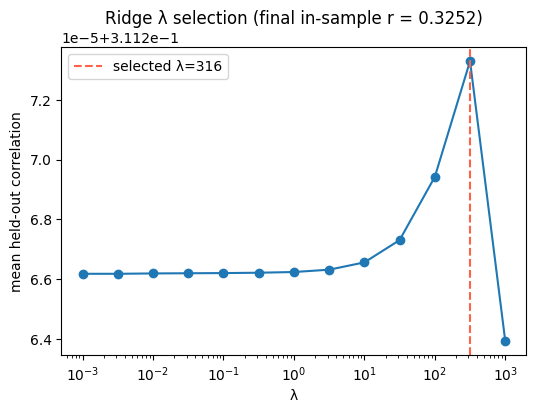

In [19]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

def ridge_metafeature_fit(X, s, fold_assignment, lambdas):
    """
    Ridge metafeature learning with spatial block CV lambda selection
    (paper Sec. 2.2). For each candidate lambda, fit on 4 folds and score
    Pearson correlation on the held-out fold; pick the lambda that maximizes
    the average held-out correlation, then refit on all data.
    """
    n_folds = fold_assignment.max() + 1
    val_corr = np.zeros((len(lambdas), n_folds))
    for li, lam in enumerate(lambdas):
        for f in range(n_folds):
            train = fold_assignment != f
            val = ~train
            ridge = Ridge(alpha=lam, fit_intercept=False).fit(X[train], s[train])
            pred = X[val] @ ridge.coef_
            val_corr[li, f], _ = pearsonr(pred, s[val])

    mean_val_corr = val_corr.mean(axis=1)
    best_lambda = lambdas[np.argmax(mean_val_corr)]

    # refit on all data at the selected lambda, normalize to the canonical direction w_hat
    ridge_final = Ridge(alpha=best_lambda, fit_intercept=False).fit(X, s)
    w_hat = ridge_final.coef_ / np.linalg.norm(ridge_final.coef_)
    q = X @ w_hat
    return w_hat, q, best_lambda, mean_val_corr

# s_T is standardized to match X_scaled's unit-variance convention, so the
# lambda grid means the same thing on both sides of the ridge loss
s_scaled = StandardScaler().fit_transform(s_T0.reshape(-1, 1)).ravel()
lambdas = np.logspace(-3, 3, 13)
w_hat0, q0, best_lambda, mean_val_corr = ridge_metafeature_fit(X_scaled, s_scaled, fold_assignment, lambdas)
corr0, _ = pearsonr(q0, s_scaled)

plt.figure(figsize=(6, 4))
plt.semilogx(lambdas, mean_val_corr, marker="o")
plt.axvline(best_lambda, color="tomato", linestyle="--", label=f"selected λ={best_lambda:.3g}")
plt.xlabel("λ")
plt.ylabel("mean held-out correlation")
plt.title(f"Ridge λ selection (final in-sample r = {corr0:.4f})")
plt.legend()
plt.show()

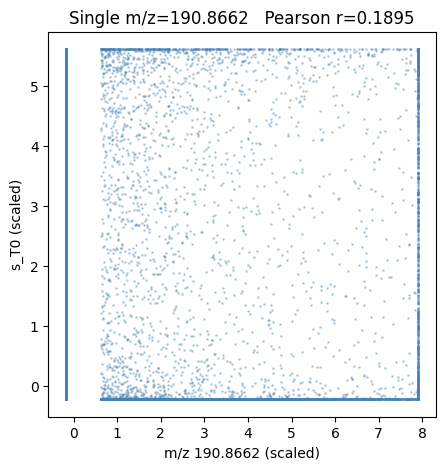

In [25]:
def test_single_mz(mz_value, mz_labels, X_scaled, s_scaled, fold_assignment, lambdas=None):
    """
    Sanity check: run the same ridge_metafeature_fit pipeline restricted to
    a single m/z channel, to see how much correlation one feature alone
    carries vs. the full metafeature combination.
    """
    if lambdas is None:
        lambdas = np.logspace(-3, 3, 13)

    idx = np.argmin(np.abs(mz_labels - mz_value))  # nearest matching m/z bin
    matched_mz = mz_labels[idx]

    X_single = X_scaled[:, [idx]]  # keep 2D shape (n, 1) for a single feature column
    w_hat, q, best_lambda, mean_val_corr = ridge_metafeature_fit(X_single, s_scaled, fold_assignment, lambdas)
    corr, _ = pearsonr(q, s_scaled)

    plt.figure(figsize=(5, 5))
    plt.scatter(q, s_scaled, s=1, alpha=0.3, c="steelblue")
    plt.xlabel(f"m/z {matched_mz:.4f} (scaled)")
    plt.ylabel("s_T0 (scaled)")
    plt.title(f"Single m/z={matched_mz:.4f}   Pearson r={corr:.4f}")
    plt.show()

    return matched_mz, corr

# example: try one specific m/z from your dataset
matched_mz, corr_sing = test_single_mz(190.8662, mz_labels, X_scaled, s_scaled, fold_assignment)

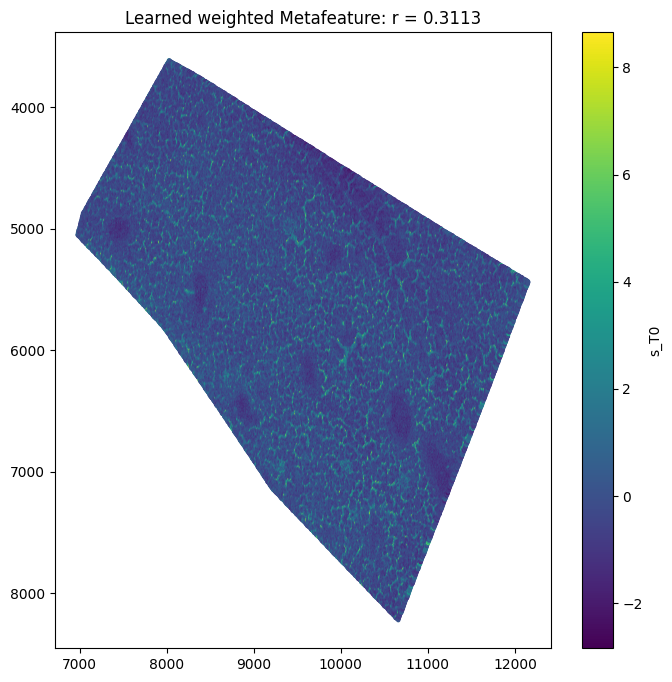

In [28]:
plt.figure(figsize=(8, 8))
plt.scatter(T0_maldi_coords[:, 0], T0_maldi_coords[:, 1], c=q0, s=4, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="s_T0")
plt.title(f"Learned weighted Metafeature: r = {np.mean(mean_val_corr):.4f}")
plt.show()

In [27]:
mean_val_corr

array([0.31126618, 0.31126618, 0.31126619, 0.3112662 , 0.3112662 ,
       0.31126621, 0.31126624, 0.31126631, 0.31126656, 0.3112673 ,
       0.31126942, 0.31127329, 0.31126392])

In [ ]:
import napari

def view_signal_on_he_napari(he_img, coords_he, values):
    """
    Napari viewer: full H&E image with a points layer, one point per MSI
    pixel at its H&E-space coordinate, colored by a continuous value.
    """
    viewer = napari.Viewer()
    viewer.add_image(he_img, name="H&E", rgb=True)

    points_yx = coords_he[:, ::-1]  # napari 2D layers use (row, col) = (y, x)
    viewer.add_points(
        points_yx,
        name="s_T0",
        features={"value": values},
        face_color="value",
        face_colormap="viridis",
        size=15,
        border_width=0,
    )
    return viewer

viewer_he = view_signal_on_he_napari(he_img, T0_maldi_coords, s_T0)